# Task 2: Customer Segmentation Using K-Means

## Objective
The goal of this project is to segment customers into different groups based on their spending habits and income.

This helps businesses understand customer behavior and create targeted marketing strategies.

In [2]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
# Load Dataset
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
# Data Info
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

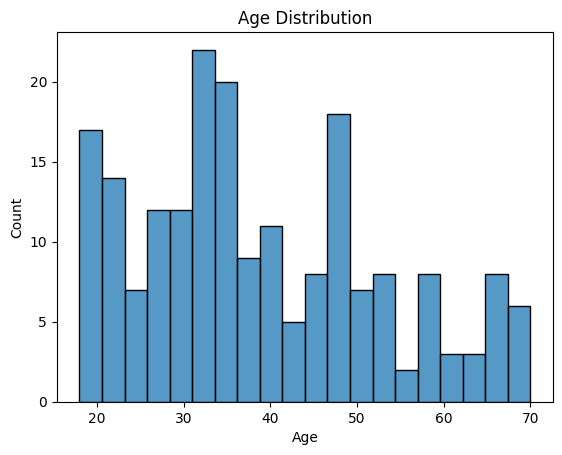

In [8]:
# EDA (Visualization)
plt.figure()
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

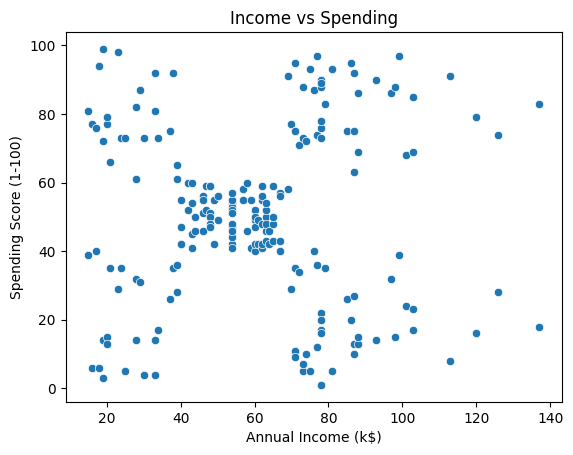

In [9]:
# Income vs Spending
plt.figure()
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    data=df
)
plt.title("Income vs Spending")
plt.show()

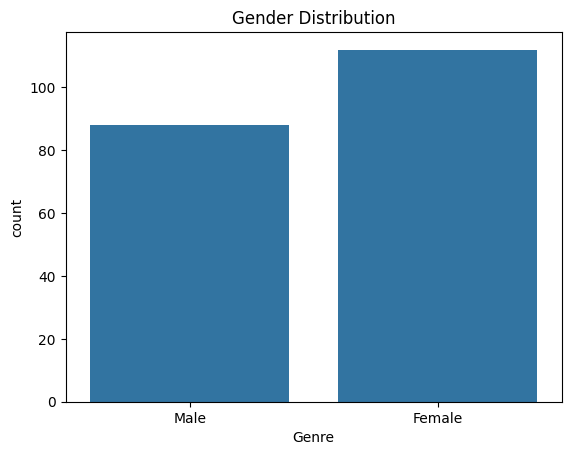

In [10]:
# Gender Count
sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()

In [11]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]   # Selecting Features

In [12]:
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

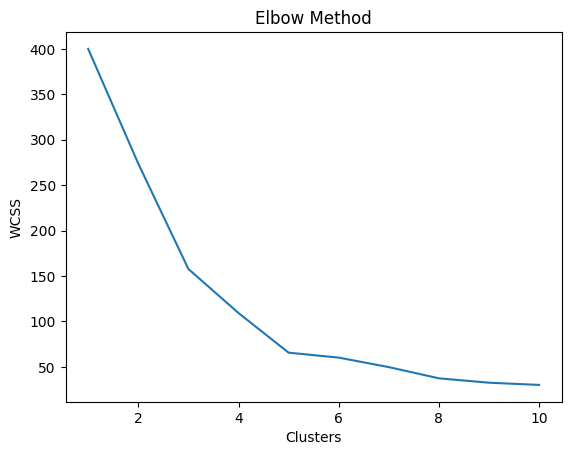

In [13]:
# Elbow Method
wcss = []

from sklearn.cluster import KMeans

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [14]:
# Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

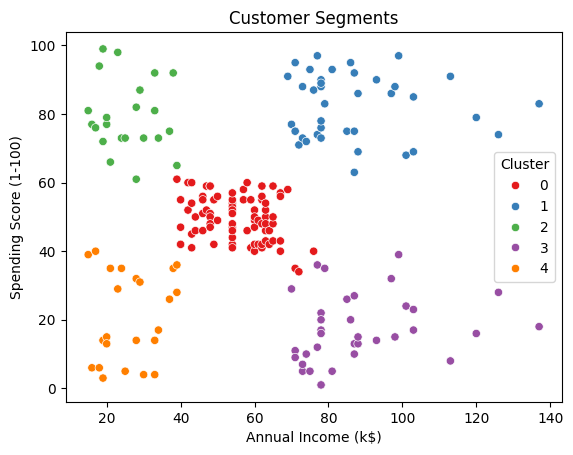

In [15]:
# Visualize Clusters
plt.figure()
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    data=df,
    palette='Set1'
)
plt.title("Customer Segments")
plt.show()

In [17]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()   # Understand Clusters

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


# Business Interpretation
Based on the output:
    
Cluster 0: 
Avg Income ≈ 55,
Spending ≈ 49
  => Average Customers

Cluster 1: 
Income ≈ 86 (HIGH),
Spending ≈ 82 (HIGH)
  => VIP Customers

Cluster 2: 
Income ≈ 25 (LOW),
Spending ≈ 79 (HIGH)
  => Impulse Buyers

Cluster 3: 
Income ≈ 88 (HIGH),
Spending ≈ 17 (LOW)
  => Careful/Rich but Low Spending

Cluster 4: 
Income ≈ 26 (LOW),
Spending ≈ 20 (LOW)
  => Low Value Customers


## Marketing Strategies

- VIP Customers: Offer premium memberships, exclusive deals
- High Income Low Spending: Target with personalized offers and discounts
- Low Income High Spending: Provide loyalty programs and small discounts
- Low Income Low Spending: Focus less marketing budget
- Average Customers: Upsell and cross-sell products

## Conclusion

Customer segmentation was successfully performed using K-Means clustering.

Five distinct customer groups were identified based on income and spending behavior.

Key Insights:
- Cluster 1 represents high-value customers with high income and high spending.
- Cluster 3 customers have high income but low spending, indicating potential for targeted marketing.
- Cluster 2 includes low-income but high-spending customers, which may indicate impulsive buying behavior.
- Cluster 4 represents low-value customers with low income and low spending.

Business Impact:
- Businesses can use these insights to design personalized marketing strategies.
- Targeted campaigns can increase customer engagement and revenue.
- Helps optimize marketing budget effectively.